In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [2]:
sales_df = pd.read_csv("outputs/sales_data.csv")
sales_df.head()


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [3]:
if "Revenue" not in sales_df.columns:
    sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Unit_Price"]

sales_df.head()


,Order_ID,Customer_ID,Product,Region,Quantity,Unit_Price,Order_Date,Revenue
0,1001,27,Accessories,West,5,60000,2024-01-01,300000
1,1002,17,Laptop,East,4,60000,2024-01-02,240000
2,1003,9,Tablet,North,5,15000,2024-01-03,75000
3,1004,33,Laptop,South,4,15000,2024-01-04,60000
4,1005,20,Accessories,South,5,8000,2024-01-05,40000


In [4]:
customer_features = (
    sales_df.groupby("Customer_ID")
    .agg(Revenue=("Revenue", "sum"),
         Total_Orders=("Order_ID", "count"),
         Quantity=("Quantity", "sum"))
    .reset_index()
)

customer_features.head()


,Customer_ID,Revenue,Total_Orders,Quantity
0,1,980000,7,24
1,2,337000,3,12
2,3,152000,4,9
3,4,113000,4,5
4,5,521000,9,24


In [5]:
customer_features["Avg_Order_Value"] = customer_features["Revenue"] / customer_features["Total_Orders"]
customer_features.head()


,Customer_ID,Revenue,Total_Orders,Quantity,Avg_Order_Value
0,1,980000,7,24,140000.000000
1,2,337000,3,12,112333.333333
2,3,152000,4,9,38000.000000
3,4,113000,4,5,28250.000000
4,5,521000,9,24,57888.888889


In [6]:
from sklearn.preprocessing import StandardScaler

X = customer_features[["Revenue", "Total_Orders", "Quantity", "Avg_Order_Value"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

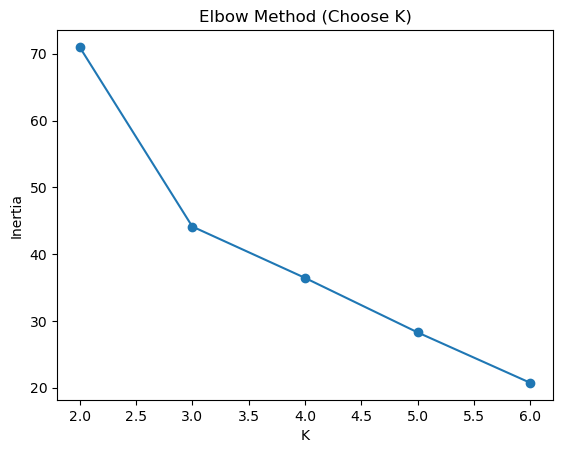

In [8]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Choose K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


In [9]:
K = 3  # change to 4 if elbow suggests better
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
customer_features["Segment"] = kmeans.fit_predict(X_scaled)

customer_features["Segment"].value_counts()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Segment
0    20
2    11
1     8
Name: count, dtype: int64

In [10]:
segment_profile = customer_features.groupby("Segment")[["Revenue", "Total_Orders", "Quantity", "Avg_Order_Value"]].mean()
segment_profile


,Revenue,Total_Orders,Quantity,Avg_Order_Value
Segment,,,,
0,165100.000000,3.15,8.150000,52245.833333
1,707750.000000,6.75,21.875000,109704.861111
2,376181.818182,3.00,9.818182,128916.666667


In [11]:
order = segment_profile["Revenue"].sort_values().index.tolist()

label_map = {}
if len(order) >= 3:
    label_map[order[0]] = "Low Value"
    label_map[order[1]] = "Medium Value"
    label_map[order[2]] = "High Value"
for i in range(3, len(order)):
    label_map[order[i]] = f"Segment {i+1}"

customer_features["Segment_Label"] = customer_features["Segment"].map(label_map)
customer_features[["Customer_ID", "Segment", "Segment_Label"]].head()


,Customer_ID,Segment,Segment_Label
0,1,1,High Value
1,2,2,Medium Value
2,3,0,Low Value
3,4,0,Low Value
4,5,1,High Value


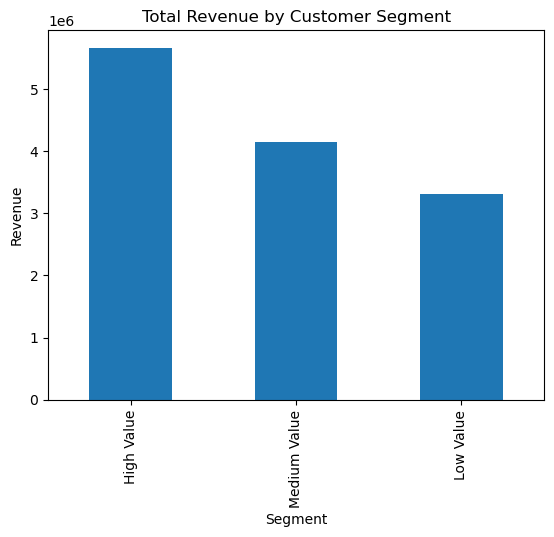

In [12]:
seg_rev = customer_features.groupby("Segment_Label")["Revenue"].sum().sort_values(ascending=False)

seg_rev.plot(kind="bar")
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()


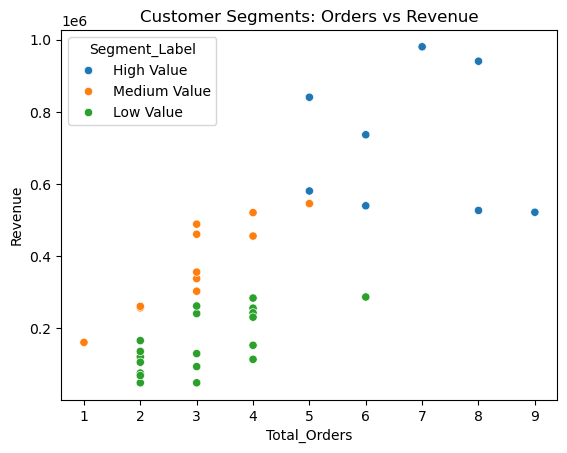

In [13]:
sns.scatterplot(data=customer_features, x="Total_Orders", y="Revenue", hue="Segment_Label")
plt.title("Customer Segments: Orders vs Revenue")
plt.show()


In [14]:
customer_features.sort_values("Revenue", ascending=False).head(10)


,Customer_ID,Revenue,Total_Orders,Quantity,Avg_Order_Value,Segment,Segment_Label
0,1,980000,7,24,140000.000000,1,High Value
32,34,940000,8,26,117500.000000,1,High Value
25,27,840000,5,23,168000.000000,1,High Value
19,21,736000,6,19,122666.666667,1,High Value
8,10,580000,5,19,116000.000000,1,High Value
11,13,545000,5,13,109000.000000,2,Medium Value
24,26,539000,6,20,89833.333333,1,High Value
15,17,526000,8,20,65750.000000,1,High Value
4,5,521000,9,24,57888.888889,1,High Value
16,18,520000,4,16,130000.000000,2,Medium Value


In [15]:
customer_features.sort_values("Revenue", ascending=False).head(10)


,Customer_ID,Revenue,Total_Orders,Quantity,Avg_Order_Value,Segment,Segment_Label
0,1,980000,7,24,140000.000000,1,High Value
32,34,940000,8,26,117500.000000,1,High Value
25,27,840000,5,23,168000.000000,1,High Value
19,21,736000,6,19,122666.666667,1,High Value
8,10,580000,5,19,116000.000000,1,High Value
11,13,545000,5,13,109000.000000,2,Medium Value
24,26,539000,6,20,89833.333333,1,High Value
15,17,526000,8,20,65750.000000,1,High Value
4,5,521000,9,24,57888.888889,1,High Value
16,18,520000,4,16,130000.000000,2,Medium Value


In [16]:
os.makedirs("outputs", exist_ok=True)

customer_features.to_csv("outputs/customer_segments.csv", index=False)

customer_features.drop(columns=["Segment", "Segment_Label"], errors="ignore")\
    .to_csv("outputs/customer_features.csv", index=False)

segment_profile.to_csv("outputs/segment_profile.csv")

print("Saved: customer_features.csv, customer_segments.csv, segment_profile.csv")


Saved: customer_features.csv, customer_segments.csv, segment_profile.csv
